# Nant de Drance — 4x5 Optimization Example

This notebook is a worked example for a multi-objective optimization
for an Nant de Drance Pumped Hydropower design problem. It shows how to:

- Define design variables and bounds
- Specify multiple objective functions and preference mappings
- Build constraints
- Run a Genetic Algorithm (GA) using two (potentially three) aggregation paradigms
- Visualize preference functions and optimization results


## Problem
Large surges of power are required to enable the acceleration of trains on heavily trafficked railways in Switzerland. These sudden demands create widespread power grid instabilities. 

To address these power drains, two existing reservoirs, the Emosson reservoir and the Vieux Emosson reservoir, were renovated to create a pumped-storage hydropower plant. During periods of excess electricity generation or reduced energy demands, plant-grenerated electricity is used to pump water from the lower reservoir to the upper reservoir. This movement enables the storing of energy in the form of gravitational potential energy. When electricity demand increases, the stored water is released
through the turbines to generate electricity and supply it back to the grid. This system takes advantage of the two reservoirs, as well as the significant height or ”head” difference to generate and store energy.

Ultimately, the closed-loop hydropower plant was selected as the preferred solution over other potential alternatives. The chosen solution enabled optimisation and retrofitting of older dam structures, focusing on sustainability and adaptive-reuse engineering. Additionally, a closed-loop system ensured a reliable and robust method of power generation, ensuring high levels of production and reduced maintenance frequencies. The chosen solution sufficiently met the requirements of all stakeholders involved. 

## Importing Required Packages

Below, the required packages are imported. To run this notebook successfully, your environment must include the required dependencies. The virtual environment provided in MUDE, called **`mude-base`**, is sufficient for this purpose.

In addition, several plotting settings are defined, and the local optimisation code is imported. It is important that the provided zip file is extracted in its entirety, as the structure of the directory is required for the imports to work correctly.

The local module `genetic_algorithm_pfm` is imported using a **relative import**, which depends on the directory structure of the project. When the notebook is executed within the provided directory structure, this will work as intended. However, running the notebook outside of this directory will result in the following error: `ModuleNotFoundError: No module named 'genetic_algorithm_pfm'`

In [2]:
# Import libraries
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import pchip_interpolate
from scipy.optimize import minimize 

# Define default plotting parameters
plt.rcParams['font.size'] = '10'  
plt.rcParams['savefig.dpi'] = 300  

# Import local module for genetic algorithm
from genetic_algorithm_pfm import GeneticAlgorithm 

## Design Variables and Bounds

The pumped hydropower plant is parameterized using four continuous design variables:

| Variable | Description | Unit | Type |
|----------|-------------|------|------|
| `x1` | Dam Height | m | Continuous |
| `x2` | Reservoir Volume | m3 | Continuous |
| `x3` | Energy Generators | [-] | Continuous |
| `x4` | Head Difference | m | Continuous | 

**Note:** In the code, design variables are defined only by their type (discrete or continuous) and their bounds — *not* by their physical meaning. Before implementing, it is good practice to write down your choice of design variables on paper, including their units and expected ranges. This helps avoid errors and builds physical intuition for the problem.



Each variable is assigned bounds that reflect physically meaningful and feasible values for a real-world pumped-storage hydropower plant design. These are defined below.

<img src="Variable_definition.png" alt="Variable definition" style="width:50%; max-width:500px; height:auto;">


`X_irl` contains a reference design based on a real-world installation, which will later be used for comparison against the optimised solutions. Its design variable values are:

In [3]:
# Define the names of variables for later use in plotting and analysis
design_variables = (
    ('x1', 'Dam Height',           'm'),
    ('x2', 'Reservoir Volume', 'm3'),
    ('x3', 'Energy Generators',       '-'),
    ('x4', 'Head Difference',     'm')
)

# set bounds for all variables
b1 = [55, 100]      # x1
b2 = [13.8e6, 40e6]   # x2
b3 = [1, 10]       # x3
b4 = [250, 500]      # x4
bounds = [b1, b2, b3, b4]

X_irl = [76.5, 25e6, 6, 425]
plot_irl = True  # Can be true or False, depending on whether you want to plot the IRL point or not

## Constraints

Constraints ensure that all solutions remain physically feasible. For this optimisation model, two physical constraints are considered: **the dam has a minimum height and the reservoir has a minimum volume (as they are pre-existing structures)**. This constraint, `constraint_1`, is a simple geometric relation corresponding to the distance `x5` shown in the figure above. A constraint function may use as many or as few design variables as necessary.

Each *constraint function* must be expressed as an algebraic expression of the form:

$$g(\mathbf{x}) \leq 0 \quad \text{(feasible)}$$

> **Important:** The constraint function should return only the value of $g(\mathbf{x})$ — do *not* encode the inequality inside the function. The inequality type (`'ineq'`) is specified separately when registering the constraint in `cons`, and the optimiser handles the comparison.

The constraints are registered as follows:

```python
cons = [['ineq', constraint_1], ['ineq', constraint_2]]
```

In [4]:
def constraint_1(variables):
    """Minimum height of dam:

    :return: 1-D array (length n) with constraint values; arr>0 means violation for 'ineq' constraints.
    """
    x1 = variables[:, 0]
    x2 = variables[:, 1]
    x3 = variables[:, 2]
    x4 = variables[:, 3]
    min_height = 55      # minimum height of dam [m]
    
    return (min_height / x1) - 1 # < 0

def constraint_2(variables):
    """Constraint placeholder: return per-individual zeros (no violation).

    :return: 1-D array (length n) with constraint values; arr>0 means violation for 'ineq' constraints.
    """
    x1 = variables[:, 0]
    x2 = variables[:, 1]
    x3 = variables[:, 2]
    x4 = variables[:, 3]
    min_vol = 13.8e6
    
    return (min_vol / x2) - 1 # < 0     # minimum volume of reservoir [m3]


cons = [['ineq', constraint_1], ['ineq', constraint_2]]

## Objective Functions

This model optimises five objectives, each representing a different stakeholder identified during the preceding stakeholder analysis. The table below summarises which objective was chosen to represent each stakeholder.

| Stakeholder | Objective | Unit |
|-------------|-----------|------|
| Nant de Drance SA | Safety | Accidents/yr |
| Government/Utility Company | Power Generated | MW |
| Commercial Stakeholders | Profit | CHF/yr |
| Local residents/Municipality | Economic Growth | CHF/yr |
| Environmental Organisations | Carbon Emissions | kg CO2 per m2 of dam |

Each objective is then expressed as a function of the design variables. Where needed, physical constants are introduced to make the units consistent — reasonable estimates are sufficient.

In [10]:
# Define objective functions

def objective_function_1(x1, x2, x3, x4):
    """
    Safety function.
    
    :return: float of expected number of Accidents per year.
    """

    cons1 = 0.15 #chance of 1 generator failing
    cons2 = 0.05 #injury during dam construction per m height of dam constructed
    cons3 = 1.2 #safety factor


    return ((cons1)**x3 + cons2 * x1) * cons3


def objective_function_2(x1, x2, x3, x4):
    """
    Power Capacity function.
    
    :return: float of energy generated per specified number of turbines.
    """
    cons4 = 360    # flow rate, Q (m3/s)
    cons5 = 0.751     # efficiency of turbine
    cons6 = 9.81     # gravitational acceleration
    cons7 = 1000   # density of water

    return ((cons5 * cons4 * cons6 * cons7 * x4) / 10e6) * x3


def objective_function_3(x1, x2, x3, x4):
    """
    Profit function.
    
    :return: float of profit per year.
    """
    cons8 = 350e6 # Initial investment
    cons9 = 0.05 # discount rate
    cons10 = 100 # lifetime
    cons11 = 150 # rated power of turbine (MW)
    cons12 = 0.2 # CF for pumped hydro
    cons13 = 8760
    AEP_per_turbine = cons11 * cons12 * cons13
    cons14 = cons8 * 0.1
    cons15 = 18 * (0.01 * 10**3) #price in CHF per MWh
    LCOE = (cons8 + ((cons14 * cons10) / ((1 + cons9)**cons10))) / (((AEP_per_turbine * x3) * cons9) / ((1 + cons9)**cons10))
    earnings = (AEP_per_turbine * x3) * cons15

    return earnings - (LCOE)


def objective_function_4(x1, x2, x3, x4):
    """
    Economic Growth function.
    
    :return: float of economic growth per year.
    """
    cons16 = 5 # Price per tourist ticket, CHF
    cons17 = 25000 # No. of tourists per year, estimated in relation to Hoover Dam
    var18 = 1.01 ** (x1 - 55) # Factor relating height of dam and tourist attraction
    var19 = 1.002 ** (x2/1e6) # Factor relating reservoir volume and tourist attraction

    return var18 * var19 * cons16 * cons17


def objective_function_5(x1, x2, x3, x4):
    """
    Carbon Emissions function.
    
    :return: float of carbon emissions per year.
    """
    cons20 = 410 # kg CO2 per 1 tonne of concrete
    cons21 = 390000 # Volume of concrete in Nant de Drance
    density = 2400 #kg/m3
    cons22 = 1.85 * 10e3 # kg CO2 per 1 tonne of steel 
    cons23 = 20000 # tonnes of steel
    length = 205 # m

    return ((cons22 * cons23) + ((cons21 * density) / 10e3) * cons20) / (x1 * length)


# Define the list of objectives with their corresponding names and units and stakeholders for later use in plotting and analysis
objectives = [
    (objective_function_1, "Safety",              "Accidents/yr",            "Nant de Drance SA"),
    (objective_function_2, "Power Generated",       "MW",            "Government/Utility"),
    (objective_function_3, "Profit", "CHF/yr",     "Commercial Stakeholders"),
    (objective_function_4, "Economic Growth",            "CHF/yr", "Local Community/Municipality"),
    (objective_function_5, "Carbon Emissions",   "kg C02/ m2",            "Environmental Orgs.")
]


While developing the objectuve functions, it can be helpful to investigate their behavior. Here the attainable minimum and maximum of each objective is computed. These ranges serve as a sanity check — if the values are physically unreasonable, revisit the formulation and its constants. The ranges also define the interval over which each objective is rated in the preference functions.

Optionally, the objective functions can be visualised using `matplotlib` or [Desmos](https://www.desmos.com/calculator) to further inspect their behaviour.

To compute the minimum and maximum values we can use the `minimize` command, which is part of the SciPy package. For more infomration see: https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.minimize.html.

In [11]:
# Finding min and max for each objective using scipy's minimize function, starting from the midpoint of the bounds
objective_minmax = {} # Dictionary to store the min and max values for each objective       
midpoints = [np.mean(b) for b in bounds]

for idx, (obj_func, name, unit, stakeholder) in enumerate(objectives):
    wrapped = lambda x, sign=1: sign * obj_func(*x)  # obj_func accepts a single array-like X
    
    min_val =  minimize(wrapped, x0=midpoints, bounds=bounds, method='L-BFGS-B').fun
    max_val = -minimize(lambda x: wrapped(x, sign=-1), x0=midpoints, bounds=bounds, method='L-BFGS-B').fun

    objective_minmax[name] = min_val, max_val
    print(f"  Objective {idx+1}  :    min = {min_val:>15,.1f}  {unit:<12}    max = {max_val:>15,.1f}  {unit}")


  Objective 1  :    min =             3.3  Accidents/yr    max =             6.2  Accidents/yr
  Objective 2  :    min =            66.3  MW              max =         1,326.1  MW
  Objective 3  :    min =    43,534,940.6  CHF/yr          max =   472,663,094.1  CHF/yr
  Objective 4  :    min =       131,902.1  CHF/yr          max =       206,401.8  CHF/yr
  Objective 5  :    min =        19,920.8  kg C02/ m2      max =        36,219.6  kg C02/ m2


## Weights

When combining multiple objectives into a single score, each objective is assigned a weight **$w_i$** reflecting its relative importance. All weights must sum to one:

$$\sum_{i=1}^{5} w_i = 1$$

| Weight | Stakeholder | Objective |
|--------|-------------|-----------|
| $w_1$ | Nant de Drance SA | Safety |
| $w_2$ | Government/Utility | Power Generated |
| $w_3$ | Commerical Stakeholders | Profit |
| $w_4$ | Local residents/Municipality | Economic Growth |
| $w_5$ | Environmental Orgs. | Carbon Emissions |

In this model, all weights are initialised equally ($w_i = \frac{1}{5} = 0.2$) for simplicity.

In [16]:
# Weights per stakeholder — must sum to 1. Before game all weights were set equal.
#                   safe   power  prof   econ  carb
#weights_before =    [0.20, 0.20, 0.20, 0.20, 0.20]
weights_after =     [0.30, 0.25, 0.20, 0.05, 0.20]

weights = weights_after  # set to which weight to use

# Verify the weights sum to 1 (within numerical tolerance)
assert np.isclose(sum(weights), 1.0), f"Weights must sum to 1, got {sum(weights)}"

## Preference Curves and Preference Functions

Each objective value is mapped to a preference score between 0 and 100 using a *preference curve*, which represents a stakeholder's preference towards their objective. This allows objectives with different units and scales to be compared and combined, where 0 indicates the least desirable outcome and 100 the most desirable.

The curves are defined by a set of control points interpolated using `pchip_interpolate` from the SciPy package, which produces smooth curves that pass exactly through each point. Only the shape of the matters — so no analytical function is needed. Creating preference curves using interpolation is a convenient and flexible approach. Start simple and increase complexity only if necessary; aim to capture the essential behaviour with as few points as possible. The prefence curves are then plotted.

For this model, two objectives are rated linearly in the technical cycle. The other three objectives follow a non-linear preference: typically denoting that money more would result in requiring more generators thus more space required, and more initial investment. 

Each preference curve is then combined with its corresponding objective function to form a *preference function*, which maps design variables directly to a preference score.

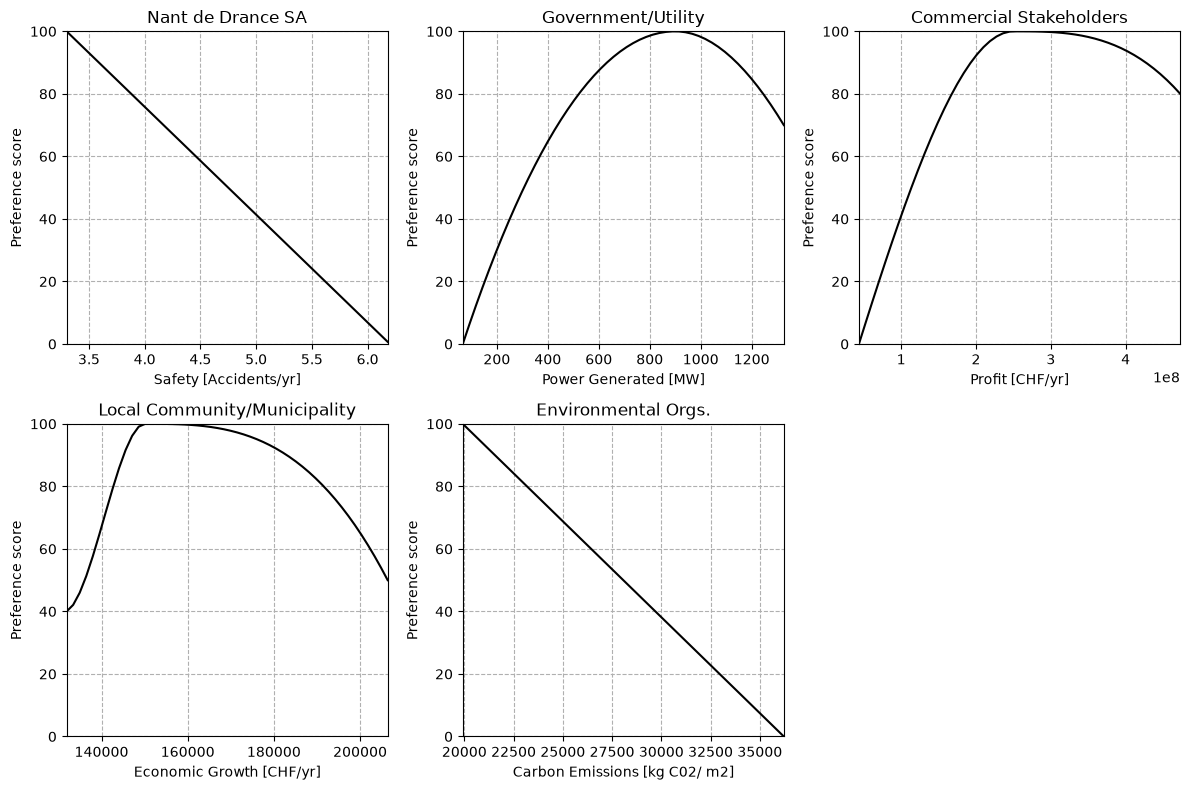

In [15]:
# Define preferences
#pref_before = [[[6.6, 12],                      [100, 0]],            #Safety
#                [[66.3, 900, 1326.1],                 [0, 100, 70]],      #Power Generated
#                [[44000000, 5000000, 473000000],             [0, 50, 100]],          #Profit
#                [[0, 7100000, 9000000, 11100000],                [0, 40, 70, 40]],   #Economic Growth
#                [[19920, 36219],                [100, 0]]]   #Carbon Emission

pref_after = [[[3.3, 6.2],                      [100, 0]],            #Safety
                [[66.3, 900, 1326.1],                 [0, 100, 70]],      #Power Generated
                [[43500000, 250000000, 473000000],             [0, 100, 80]],          #Profit
                [[0, 131902.1, 150000, 206401.8],                [0, 40, 100, 50]],   #Economic Growth
                [[19920, 36219],                [100, 0]]]   #Carbon Emission

prefs = pref_after  # set to which preferences to use


# Preference curve values for plotting
# Generate objective value ranges 
obj_vals_list = []
for _, name, _, _ in objectives:
    obj_vals = np.linspace(*objective_minmax[name])
    obj_vals_list.append(obj_vals)

# Generate preference values using interpolation
pref_vals_list = []
for pref, obj_vals in zip(prefs, obj_vals_list):
    pref_vals = pchip_interpolate(pref[0], pref[1], obj_vals)
    pref_vals_list.append(pref_vals)

# Plotting the preference curves 
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for ax, (obj_vals, p_vals), (_, name, unit, stakeholder) in zip(axes.flat, zip(obj_vals_list, pref_vals_list), objectives): # Loop to plot each preference curve in its own subplot
    ax.plot(obj_vals, p_vals, color='black')
    ax.set_xlim(min(obj_vals), max(obj_vals))
    ax.set_ylim(0, 100)
    ax.set_title(stakeholder)
    ax.set_xlabel(f'{name} [{unit}]')
    ax.set_ylabel('Preference score')
    ax.grid(linestyle='--')

axes.flat[-1].set_visible(False)  # hide empty 6th subplot
fig.tight_layout()
# plt.savefig('preference_curves.png')  # Uncomment this line to save the figure as a PNG file
plt.show()


# Defines preference functions that convert raw objective values to 0-100 preference scores
def pref_func_1(x1, x2, x3, x4):
    cost = objective_function_1(x1, x2, x3, x4)
    return pchip_interpolate(prefs[0][0], prefs[0][1], cost)

def pref_func_2(x1, x2, x3, x4):
    ride = objective_function_2(x1, x2, x3, x4)
    return pchip_interpolate(prefs[1][0], prefs[1][1], ride)

def pref_func_3(x1, x2, x3, x4):
    sed = objective_function_3(x1, x2, x3, x4)
    return pchip_interpolate(prefs[2][0], prefs[2][1], sed)

def pref_func_4(x1, x2, x3, x4):
    safe = objective_function_4(x1, x2, x3, x4)
    return pchip_interpolate(prefs[3][0], prefs[3][1], safe)

def pref_func_5(x1, x2, x3, x4):
    econ = objective_function_5(x1, x2, x3, x4)
    return pchip_interpolate(prefs[4][0], prefs[4][1], econ)

pref_funcs = [pref_func_1, pref_func_2, pref_func_3, pref_func_4, pref_func_5]  # list of preference functions for easier handling


def objective(variables):
    """
    Objective function that is fed to the GA. Calles the separate preference functions that are declared above.

    :param variables: array with design variable values per member of the population. Can be split by using array
    slicing
    :return: 1D-array with aggregated preference scores for the members of the population.
    """
    x1 = variables[:, 0]
    x2 = variables[:, 1]
    x3 = variables[:, 2]
    x4 = variables[:, 3]

    # calculate the preference scores
    p_1 = pref_func_1(x1, x2, x3, x4)
    p_2 = pref_func_2(x1, x2, x3, x4)
    p_3 = pref_func_3(x1, x2, x3, x4)
    p_4 = pref_func_4(x1, x2, x3, x4)
    p_5 = pref_func_5(x1, x2, x3, x4)
    
    return weights, [p_1, p_2, p_3, p_4, p_5]

## Optimisation

Now that everything is in place, we can run the optimisation. For more details on the available configuration options, see the docstring of `GeneticAlgorithm` (accessible via `help()`). Note that a genetic algorithm relies on randomness, so it is expected that results will differ slightly between separate executions.

The optimisation can be run using three aggregation methods: `'minmax'`, `'a-fine'`, and optionally `'tetra'`. These methods differ in how the individual preference scores are combined into a group preference during the optimisation process; see `aggregations.md` for more information on how each method works and when to use it. These methods determine, mathematically, what is considered the "best" group preference. However, what is considered "best" is not purely a mathematical question, it also involves a qualitative judgement about which outcome is most appropriate for the problem at hand.

After computing the optimal results, the solutions are plotted on top of their corresponding preference curves.


Run GA with minmax
The type of aggregation is set to minmax
Generation   Best score   Mean             Max stall    Diversity    Number of non-feasible results
0            10.0377      18.1623          0            0.004        0           
1            9.9871       12.2785          0            0.074        0           
2            9.9871       10.8891          1            0.132        0           
3            9.9871       10.586           2            0.23         0           
4            9.9871       10.3261          3            0.232        0           
5            9.9871       10.3273          4            0.232        0           
6            9.9871       10.2406          5            0.233        0           
7            9.9871       10.3114          6            0.232        0           
8            9.9871       10.2881          7            0.23         0           
9            9.9871       10.2843          8            0.236        0           
10           9.9871

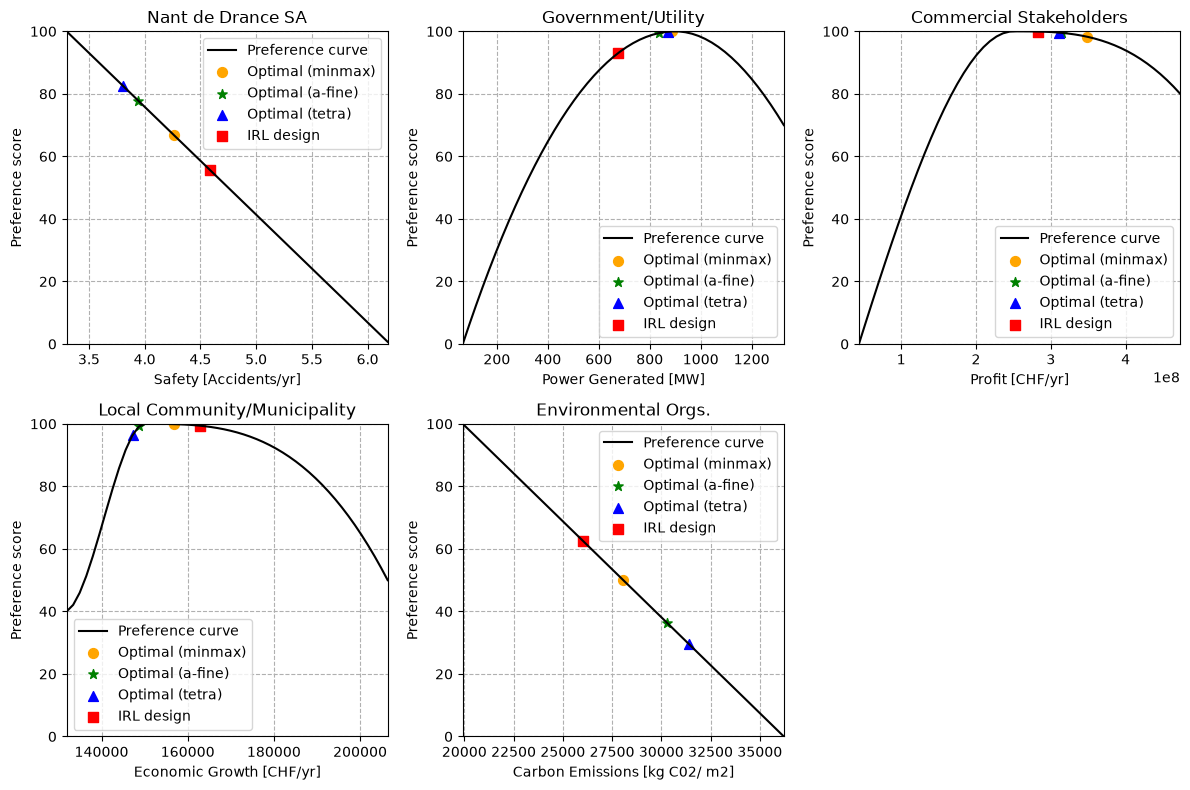

In [17]:
# We run the optimization with two paradigms
paradigm = ['minmax', 'a-fine', 'tetra']  # 'minmax' or 'a-fine' or 'tetra'
markers  = ['o', '*', '^']  # we added here '^'
colours  = ['orange', 'green', 'blue'] # we added here 'blue'

# Define the figure and axes before the loop
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

# Plot underlying preference curves using a loop
for ax, o_vals, p_vals, (_, name, unit, stakeholder) in zip(axes.flat, obj_vals_list, pref_vals_list, objectives): 
    ax.plot(o_vals, p_vals, color='black', label='Preference curve')
    ax.set_xlim(min(o_vals), max(o_vals))
    ax.set_ylim(0, 100)
    ax.set_title(stakeholder)
    ax.set_xlabel(f'{name} [{unit}]')
    ax.set_ylabel('Preference score')
    ax.grid(linestyle='--')

for i in range(len(paradigm)):
    # Dictionary with parameter settings for the GA run with the IMAP solver
    options = {
        'n_bits': 8,
        'n_iter': 400,
        'n_pop': 500,
        'r_cross': 0.8,
        'max_stall': 16,
        'aggregation': paradigm[i],  
        'var_type': 'real'
    }

    # Run the GA and print its result
    print(f'\nRun GA with {paradigm[i]}')
    ga = GeneticAlgorithm(objective=objective, constraints=cons, bounds=bounds, options=options)
    _, optimal_design_var, _ = ga.run()

    # print the optimal design variable values
    print(f'Optimal design variable values using {paradigm[i]}:') 
    for opt_var, (xi, name, unit) in zip(optimal_design_var, design_variables):
        print(f'  {xi} : {name:<25} = {opt_var:>10.2f} {unit}') 

    # Print and plot the optimal objective results and stakeholder preferences
    print(f'Optimal objective results and stakeholder preference using {paradigm[i]}:')
    for j, (ax, (obj_func, name, unit, stakeholder)) in enumerate(zip(axes.flat, objectives)):
        obj_value = obj_func(*optimal_design_var) # Calculate resulting objective value
        pref_score = pref_funcs[j](*optimal_design_var) # Calculate resulting preference score
    
        # Print and plot the optimal point on the preference curve
        print(f'  {name:<20} = {obj_value:>15,.2f} {unit:<10} -> {stakeholder:<20} pref: {pref_score:>6.2f}')
        ax.scatter(obj_value, pref_score, color=colours[i], marker=markers[i], s=50,
                   label=f'Optimal ({paradigm[i]})')


# plot the IRL design point if plot_irl is True
if plot_irl:   
    irl_obj_values = [obj_func(*X_irl) for obj_func, _, _, _ in objectives]
    irl_pref_scores = [pref_funcs[j](*X_irl) for j in range(len(objectives))]
    for j, ax in enumerate(axes.flat[:5]):
        ax.scatter(irl_obj_values[j], irl_pref_scores[j], color='red', marker='s', s=50, label='IRL design')

for ax in axes.flat[:5]:
    ax.legend(fontsize=10)

axes.flat[-1].set_visible(False)  # hide the sixth empty subplot


# Adjust the layout 
fig.tight_layout()

# Save figure
# plt.savefig('optimal_results.png')  # Uncomment this line to save the figure as a PNG file

# Display the plot
plt.show()